In [4]:
# ============================================================
# 1. IMPORTS
# ============================================================

import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("Imports loaded successfully")

Imports loaded successfully


In [5]:
# ============================================================
# 2. PROJECT PATH AND INTERNAL MODULES
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data_pipeline
import src.events

importlib.reload(src.data_pipeline)
importlib.reload(src.events)

from src.data_pipeline import ModelDatasetBuilder
from src.events import SimpleEventDetector

print("Internal modules loaded successfully")

Internal modules loaded successfully


In [6]:
# ============================================================
# 3. DATABASE PATH AND BUILDER
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

print("DB exists:", db_path.exists())
print("DB path:", db_path)

builder = ModelDatasetBuilder(db_path)

print("Builder created successfully")

DB exists: True
DB path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db
Builder created successfully


In [7]:
# ============================================================
# 4. LOAD DATA FOR LSTM
# ============================================================

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2020-12-31",
    add_time_features=True,
    lags=[1, 2, 24, 48, 168],
    target_horizon=1,
    include_volumes=True,
    dropna=False
)

print("Dataset shape:", df.shape)
print("Start:", df.index.min())
print("End:", df.index.max())

df.head()

Dataset shape: (8761, 17)
Start: 2020-01-01 00:00:00
End: 2020-12-31 00:00:00


,price_id,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,price_value_lag_48,price_value_lag_168,target
datetime,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,0,31.77,4091.8,1819.6,2020,1,1,2,NaN,NaN,NaN,NaN,NaN,31.57
2020-01-01 01:00:00,52,12,2020-01-01,1,31.57,4021.3,1826.2,2020,1,1,2,31.77,NaN,NaN,NaN,NaN,31.28
2020-01-01 02:00:00,72,12,2020-01-01,2,31.28,3975.7,1836.8,2020,1,1,2,31.57,31.77,NaN,NaN,NaN,30.72
2020-01-01 03:00:00,92,12,2020-01-01,3,30.72,3993.6,1841.5,2020,1,1,2,31.28,31.57,NaN,NaN,NaN,30.27
2020-01-01 04:00:00,112,12,2020-01-01,4,30.27,4041.5,1798.0,2020,1,1,2,30.72,31.28,NaN,NaN,NaN,30.17


In [21]:
# ============================================================
# 5. PRICE + VOLUME EVENT DETECTION
# ============================================================

detector = SimpleEventDetector()

# Price events
df_events = detector.detect_price_events(df)

# Volume events
df_events = detector.detect_volume_events(df_events)

print("Dataset with price and volume events shape:", df_events.shape)

# Check some generated event columns
event_cols_check = [
    # Price events
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility",

    # Volume events
    "high_demand",
    "low_demand",
    "high_generation",
    "low_generation",
    "volume_imbalance",
    "strong_buy_pressure",
    "strong_sell_pressure",
    "buy_volume_delta",
    "sell_volume_delta",
    "abs_buy_volume_delta",
    "abs_sell_volume_delta",
    "buy_volume_spike",
    "sell_volume_spike",
]

df_events[event_cols_check].head()

Dataset with price and volume events shape: (8761, 41)


,low_price,high_price,price_spike,extreme_price,rapid_price_change,price_ramp_up,price_ramp_down,high_volatility,high_demand,low_demand,...,low_generation,volume_imbalance,strong_buy_pressure,strong_sell_pressure,buy_volume_delta,sell_volume_delta,abs_buy_volume_delta,abs_sell_volume_delta,buy_volume_spike,sell_volume_spike
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,False,True,True,True,False,False,False,False,False,False,...,False,0.384376,False,False,NaN,NaN,NaN,NaN,False,False
2020-01-01 01:00:00,False,True,True,True,False,False,False,False,False,False,...,False,0.375391,False,False,-70.5,6.6,70.5,6.6,False,False
2020-01-01 02:00:00,False,True,True,True,False,False,False,False,False,False,...,False,0.367983,False,False,-45.6,10.6,45.6,10.6,False,False
2020-01-01 03:00:00,False,True,True,True,False,False,False,False,False,False,...,False,0.368820,False,False,17.9,4.7,17.9,4.7,False,False
2020-01-01 04:00:00,False,True,True,False,False,False,False,False,False,False,...,False,0.384194,False,False,47.9,-43.5,47.9,43.5,False,False


In [23]:
# ============================================================
# 7. CYCLICAL TIME FEATURES
# ============================================================

df_events = df_events.copy()

df_events["hour"] = df_events.index.hour
df_events["dayofweek"] = df_events.index.dayofweek

df_events["hour_sin"] = np.sin(2 * np.pi * df_events["hour"] / 24)
df_events["hour_cos"] = np.cos(2 * np.pi * df_events["hour"] / 24)

df_events["dayofweek_sin"] = np.sin(2 * np.pi * df_events["dayofweek"] / 7)
df_events["dayofweek_cos"] = np.cos(2 * np.pi * df_events["dayofweek"] / 7)

df_events[
    [
        "hour",
        "hour_sin",
        "hour_cos",
        "dayofweek",
        "dayofweek_sin",
        "dayofweek_cos"
    ]
].head()

,hour,hour_sin,hour_cos,dayofweek,dayofweek_sin,dayofweek_cos
datetime,,,,,,
2020-01-01 00:00:00,0,0.000000,1.000000,2,0.974928,-0.222521
2020-01-01 01:00:00,1,0.258819,0.965926,2,0.974928,-0.222521
2020-01-01 02:00:00,2,0.500000,0.866025,2,0.974928,-0.222521
2020-01-01 03:00:00,3,0.707107,0.707107,2,0.974928,-0.222521
2020-01-01 04:00:00,4,0.866025,0.500000,2,0.974928,-0.222521


In [24]:
# ============================================================
# 8. SELECT FEATURES AND TARGET - PRICE + VOLUME EVENTS
# ============================================================

features_lstm = [
    # Base price
    "price_value",

    # Calendar features
    "year",
    "month",
    "day",
    "day_of_week",

    # Cyclical time features
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",

    # Price lags
    "price_value_lag_1",
    "price_value_lag_2",
    "price_value_lag_24",
    "price_value_lag_48",
    "price_value_lag_168",

    # Price events
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility",

    # Volume base
    "buy_volume_value",
    "sell_volume_value",

    # Volume level events
    "high_demand",
    "low_demand",
    "high_generation",
    "low_generation",

    # Buy / sell pressure
    "volume_imbalance",
    "strong_buy_pressure",
    "strong_sell_pressure",

    # Dynamic volume features
    "buy_volume_delta",
    "sell_volume_delta",
    "abs_buy_volume_delta",
    "abs_sell_volume_delta",
    "buy_volume_spike",
    "sell_volume_spike",
]

target_col = "target"

df_lstm = df_events[features_lstm + [target_col]].dropna().copy()

X_raw = df_lstm[features_lstm]
y_raw = df_lstm[target_col]

print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)
print("Number of features:", len(features_lstm))
print("Start:", df_lstm.index.min())
print("End:", df_lstm.index.max())

X_raw.head()

X shape: (8592, 37)
y shape: (8592,)
Number of features: 37
Start: 2020-01-08 00:00:00
End: 2020-12-30 23:00:00


,price_value,year,month,day,day_of_week,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,price_value_lag_1,...,low_generation,volume_imbalance,strong_buy_pressure,strong_sell_pressure,buy_volume_delta,sell_volume_delta,abs_buy_volume_delta,abs_sell_volume_delta,buy_volume_spike,sell_volume_spike
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-08 00:00:00,24.82,2020,1,8,2,0.000000,1.000000,0.974928,-0.222521,24.46,...,False,0.373789,False,False,-103.6,9.8,103.6,9.8,False,False
2020-01-08 01:00:00,22.50,2020,1,8,2,0.258819,0.965926,0.974928,-0.222521,24.82,...,False,0.366939,False,False,-81.6,-6.7,81.6,6.7,False,False
2020-01-08 02:00:00,20.42,2020,1,8,2,0.500000,0.866025,0.974928,-0.222521,22.50,...,False,0.368428,False,False,-27.4,-19.3,27.4,19.3,False,False
2020-01-08 03:00:00,20.01,2020,1,8,2,0.707107,0.707107,0.974928,-0.222521,20.42,...,False,0.384281,False,False,13.5,-63.5,13.5,63.5,False,False
2020-01-08 04:00:00,23.00,2020,1,8,2,0.866025,0.500000,0.974928,-0.222521,20.01,...,False,0.381500,False,False,148.5,78.6,148.5,78.6,False,False


In [25]:
# ============================================================
# 9. TEMPORAL TRAIN / TEST SPLIT
# ============================================================

train_end = "2020-11-30 23:00:00"
test_start = "2020-12-01 00:00:00"
test_end = "2020-12-08 00:00:00"

train_mask = df_lstm.index <= train_end
test_mask = (df_lstm.index >= test_start) & (df_lstm.index <= test_end)

X_train_raw = X_raw.loc[train_mask]
X_test_raw = X_raw.loc[test_mask]

y_train_raw = y_raw.loc[train_mask]
y_test_raw = y_raw.loc[test_mask]

print("X train:", X_train_raw.shape)
print("X test:", X_test_raw.shape)
print("y train:", y_train_raw.shape)
print("y test:", y_test_raw.shape)

print("Train start:", X_train_raw.index.min())
print("Train end:", X_train_raw.index.max())
print("Test start:", X_test_raw.index.min())
print("Test end:", X_test_raw.index.max())

X train: (7872, 37)
X test: (169, 37)
y train: (7872,)
y test: (169,)
Train start: 2020-01-08 00:00:00
Train end: 2020-11-30 23:00:00
Test start: 2020-12-01 00:00:00
Test end: 2020-12-08 00:00:00


In [26]:
# ============================================================
# 10. SCALING
# ============================================================

scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(X_train_raw)
scaler_y.fit(y_train_raw.values.reshape(-1, 1))

X_scaled = pd.DataFrame(
    scaler_X.transform(X_raw),
    index=X_raw.index,
    columns=X_raw.columns
)

y_scaled = pd.Series(
    scaler_y.transform(y_raw.values.reshape(-1, 1)).ravel(),
    index=y_raw.index,
    name=target_col
)

print("Scaled X shape:", X_scaled.shape)
print("Scaled y shape:", y_scaled.shape)

Scaled X shape: (8592, 37)
Scaled y shape: (8592,)


In [27]:
# ============================================================
# 11. CREATE LSTM SEQUENCES FUNCTION
# ============================================================

def create_lstm_sequences(X, y, lookback):
    X_seq = []
    y_seq = []
    seq_index = []

    for i in range(lookback, len(X)):
        X_seq.append(X.iloc[i - lookback:i].values)
        y_seq.append(y.iloc[i])
        seq_index.append(y.index[i])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    seq_index = pd.Index(seq_index)

    return X_seq, y_seq, seq_index

print("Function created successfully")

Function created successfully


In [28]:
# ============================================================
# 12. CREATE LSTM DATASET
# ============================================================

lookback = 24

X_seq, y_seq, seq_index = create_lstm_sequences(
    X_scaled,
    y_scaled,
    lookback
)

train_seq_mask = seq_index <= train_end
test_seq_mask = (seq_index >= test_start) & (seq_index <= test_end)

X_train_lstm = X_seq[train_seq_mask]
y_train_lstm = y_seq[train_seq_mask]

X_test_lstm = X_seq[test_seq_mask]
y_test_lstm = y_seq[test_seq_mask]

y_test_index_lstm = seq_index[test_seq_mask]

print("X_train_lstm:", X_train_lstm.shape)
print("y_train_lstm:", y_train_lstm.shape)
print("X_test_lstm:", X_test_lstm.shape)
print("y_test_lstm:", y_test_lstm.shape)
print("Test index start:", y_test_index_lstm.min())
print("Test index end:", y_test_index_lstm.max())

X_train_lstm: (7848, 24, 37)
y_train_lstm: (7848,)
X_test_lstm: (169, 24, 37)
y_test_lstm: (169,)
Test index start: 2020-12-01 00:00:00
Test index end: 2020-12-08 00:00:00


In [29]:
# ============================================================
# 13. DEFINE LSTM MODEL
# ============================================================

n_timesteps = X_train_lstm.shape[1]
n_features = X_train_lstm.shape[2]

lstm_model = Sequential([
    LSTM(
        units=64,
        input_shape=(n_timesteps, n_features),
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

lstm_model.summary()

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        26,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,225 (110.25 KB)

 Trainable params: 28,225 (110.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# ============================================================
# 14. TRAIN LSTM MODEL
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3153 - val_loss: 0.3318
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0636 - val_loss: 0.2469
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0361 - val_loss: 0.2184
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0339 - val_loss: 0.2129
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0282 - val_loss: 0.2294
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0318 - val_loss: 0.2722
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0315 - val_loss: 0.2450
Epoch 8/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0258 - val_loss: 0.2067
Epoch 9/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0213 - val_loss: 0.1954
Epoch 10/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0199 - val_loss: 0.1985
Epoch 11/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0201 - val_loss: 0.2158
Epoch 12/100
197/197 ━━━━━━━━━━━━━━━━━━━

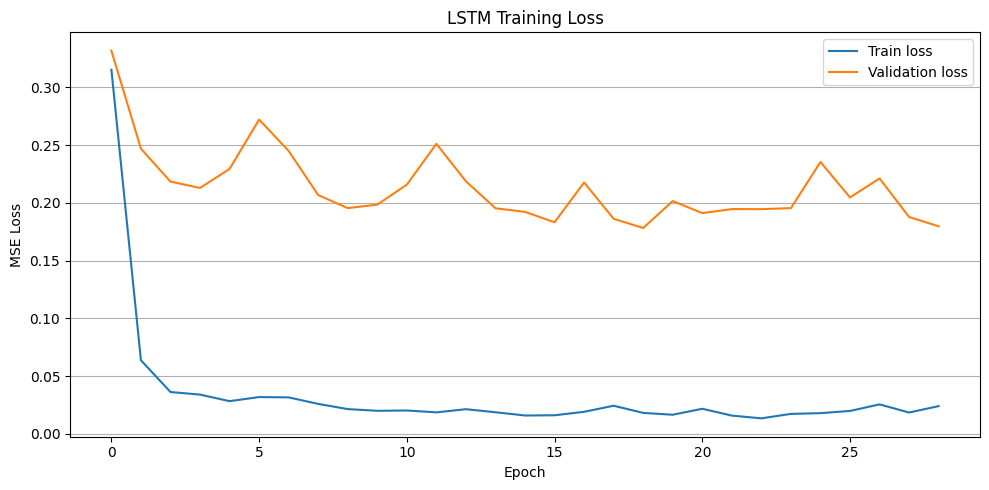

In [31]:
# ============================================================
# 15. TRAINING LOSS PLOT
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# 16. PREDICTIONS AND INVERSE SCALING
# ============================================================

y_pred_lstm_scaled = lstm_model.predict(X_test_lstm).ravel()

y_pred_lstm = scaler_y.inverse_transform(
    y_pred_lstm_scaled.reshape(-1, 1)
).ravel()

y_test_lstm_real = scaler_y.inverse_transform(
    y_test_lstm.reshape(-1, 1)
).ravel()

lstm_pred_series = pd.Series(
    y_pred_lstm,
    index=y_test_index_lstm,
    name="LSTM_prediction"
)

y_test_lstm_series = pd.Series(
    y_test_lstm_real,
    index=y_test_index_lstm,
    name="Real"
)

print("Predictions created successfully")
print(lstm_pred_series.head())

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predictions created successfully
2020-12-01 00:00:00    13.190089
2020-12-01 01:00:00    12.608134
2020-12-01 02:00:00    14.083534
2020-12-01 03:00:00    15.089878
2020-12-01 04:00:00    15.876504
Name: LSTM_prediction, dtype: float32


In [33]:
# ============================================================
# 17. EVALUATION
# ============================================================

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

lstm_results = evaluate_model(
    y_test_lstm_series,
    lstm_pred_series
)

lstm_results_df = pd.DataFrame({
    "LSTM_24h": lstm_results
}).T

lstm_results_df

,MAE,RMSE,R2
LSTM_24h,1.554684,2.188755,0.539403


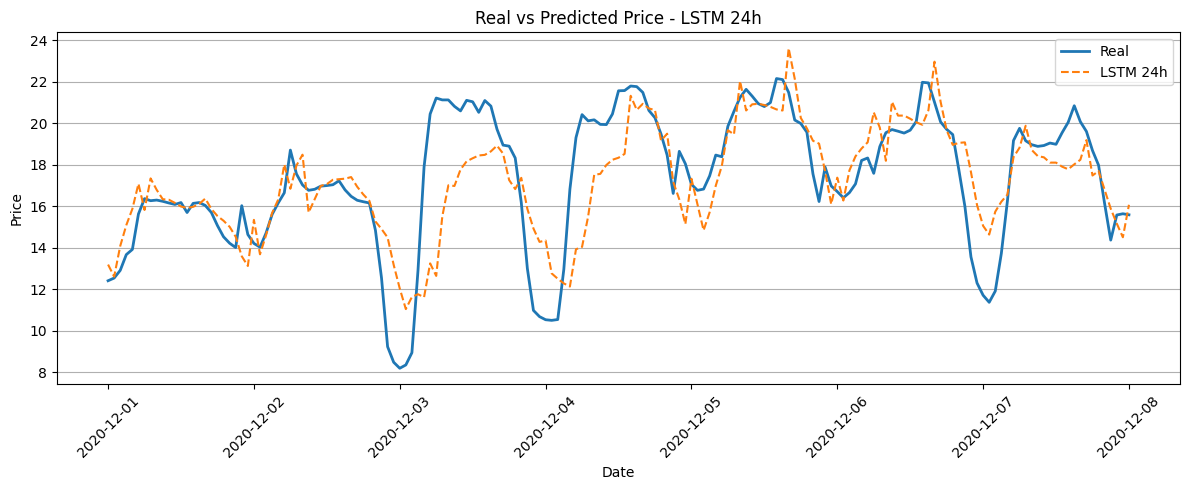

In [34]:
# ============================================================
# 18. REAL VS PREDICTED - LSTM
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_lstm_series.index,
    y_test_lstm_series.values,
    label="Real",
    linewidth=2
)

plt.plot(
    lstm_pred_series.index,
    lstm_pred_series.values,
    label="LSTM 24h",
    linestyle="--"
)

plt.title("Real vs Predicted Price - LSTM 24h")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()